# When to Use AUC-ROC

### Ideal Use Cases

AUC-ROC is effective when:

- The dataset is balanced and the model needs to be evaluated across all thresholds.
- False positives and false negatives are of similar importance.

### Limitations with Imbalanced Data

In cases of highly imbalanced datasets, AUC-ROC might give overly optimistic results. In such cases, the Precision-Recall Curve is more suitable, as it focuses on the positive class.

### Model Performance with AUC-ROC

- **High AUC (close to 1):** The model effectively distinguishes between positive and negative instances.
- **Low AUC (close to 0):** The model struggles to differentiate between the two classes.
- **AUC around 0.5:** The model doesn't learn any meaningful patterns—it is performing random guessing.

### Summary

In short, AUC gives you an overall idea of how well your model is doing at sorting positives and negatives, without being affected by the threshold you set for classification. A higher AUC means your model is performing well.

## <br>Implementation using two different models

### 2. Generating data and splitting data

Using an 80-20 split ratio, the algorithm creates artificial binary classification data with 20 features, divides it into training and testing sets and assigns a random seed to ensure reproducibility.

### 3. Training the different models

To train the Random Forest and Logistic Regression models we use a fixed random seed to get the same results every time we run the code. First we train a logistic regression model using the training data. Then use the same training data and random seed we train a Random Forest model with 100 trees.

### 4. Predictions

Using the test data and a trained Logistic Regression model the code predicts the positive class's probability. In a similar manner, using the test data, it uses the trained Random Forest model to produce projected probabilities for the positive class.

### 5. Creating a dataframe

Using the test data the code creates a DataFrame called test_df with columns labeled "True," "Logistic" and "RandomForest," add true labels and predicted probabilities from Random Forest and Logistic Regression models.

### 6. Plotting ROC Curve for models

Plot the ROC curve and compute the AUC for both Logistic Regression and Random Forest. The ROC curve compares models based on True Positive Rate vs False Positive Rate, while the red dashed line shows random guessing. The plot computes the AUC and ROC curve for each model i.e Random Forest and Logistic Regression, then plots the ROC curve. The ROC curve for random guessing is also represented by a red dashed line and labels, a title and a legend are set for visualization.

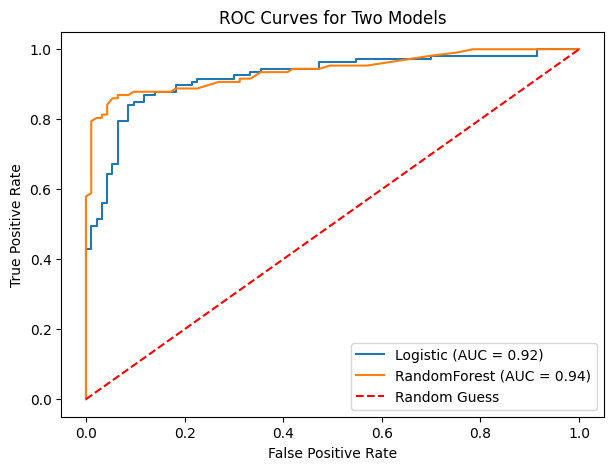

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc


# 2. Generating data and splitting data
X, Y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# 3. Training the different models
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, Y_train)

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, Y_train)


# 4. Predictions
y_logistic_prediction = logistic_model.predict_proba(X_test)[:, 1]
y_random_forest_prediction = random_forest_model.predict_proba(X_test)[:, 1]

# 5. Creating a dataframe
test_df = pd.DataFrame({
                        'True': Y_test, 
                        'Logistic': y_logistic_prediction, 
                        'RandomForest': y_random_forest_prediction
                    })
test_df.head()


# 6. Plotting ROC Curve for models
plt.figure(figsize=(7, 5))

for model in ['Logistic', 'RandomForest']:
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Two Models')

plt.legend()

plt.show()